In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from statsmodels.tsa.seasonal import seasonal_decompose
from tensorflow.python.ops.ragged.ragged_array_ops import cross_hashed

In [18]:
df = pd.read_excel('Data_Set/Data_Set_7.xlsx', sheet_name='qrySales')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

pivot_df = df.pivot_table(index='OrderDate', columns='CustomerCountry', values='Revenue', aggfunc='sum').fillna(0)

monthly_sales = pivot_df.resample('ME').sum()
monthly_sales.head()

CustomerCountry,Argentina,Austria,Belgium,Brazil,Canada,Denmark,Finland,France,Germany,Ireland,...,Mexico,Norway,Poland,Portugal,Spain,Sweden,Switzerland,UK,USA,Venezuela
OrderDate,,,,,,,,,,,,,,,,,,,,,
2008-01-31,4536.00,0.00,1511.0,11022.50,568.95,237.9,3523.40,20232.79,8456.81,0.0,...,660.0,0.00,0.0,735.00,0.0,3884.95,3388.0,7136.40,18319.52,11998.50
2008-02-29,19020.00,0.00,0.0,11556.70,2950.50,1630.0,1924.25,8502.51,6391.65,0.0,...,0.0,0.00,1988.5,0.00,70.0,2191.10,2086.0,24131.14,4951.05,5654.15
2008-03-31,7871.30,2772.00,1299.0,10605.35,11659.30,0.0,0.00,8146.80,6694.80,0.0,...,1424.8,365.89,0.0,0.00,1805.4,2034.50,1255.6,15864.45,14839.70,17681.50
2008-04-30,10721.49,7993.31,0.0,21839.15,3345.18,0.0,10466.50,8129.00,14586.65,0.0,...,0.0,361.00,1863.6,3658.75,3592.0,0.00,5011.8,24054.40,8913.15,6148.58
2008-05-31,0.00,300.00,0.0,5578.00,0.00,0.0,928.75,1301.30,2471.65,0.0,...,0.0,0.00,0.0,0.00,586.0,0.00,0.0,4722.30,1873.50,762.56


In [19]:
df

,CustomerID,CustomerName,OrderDate,ProductName,EmployeeName,SupplierName,Paid?,CustomerCountry,CustomerState/Region,CustomerCity,UnitPrice,Quantity,Revenue
0,1090,Aakash Patel,2009-10-06,Tourtière,Janet Leverling,Ma Maison,Yes,Finland,NaN,Helsinki,7.45,60,447.0
1,1090,Aakash Patel,2009-03-10,Pavlova,Nancy Davolio,"Pavlova, Ltd.",Yes,Finland,NaN,Helsinki,13.90,35,486.5
2,1090,Aakash Patel,2008-10-01,Northwoods Cranberry Sauce,Margaret Peacock,Grandma Kelly's Homestead,Yes,Finland,NaN,Helsinki,32.00,70,2240.0
3,1090,Aakash Patel,2008-10-01,Chef Anton's Cajun Seasoning,Margaret Peacock,New Orleans Cajun Delights,Yes,Finland,NaN,Helsinki,17.60,35,616.0
4,1090,Aakash Patel,2009-04-10,Sirop d'érable,Margaret Peacock,Forêts d'érables,Yes,Finland,NaN,Helsinki,28.50,25,712.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,1054,Zachary McLeer,2009-04-24,Outback Lager,Janet Leverling,"Pavlova, Ltd.",Yes,Argentina,NaN,Buenos Aires,15.00,6,90.0
2151,1054,Zachary McLeer,2008-04-29,Outback Lager,Janet Leverling,"Pavlova, Ltd.",No,Argentina,NaN,Buenos Aires,15.00,3,45.0
2152,1054,Zachary McLeer,2009-04-24,Raclette Courdavault,Janet Leverling,Gai pâturage,Yes,Argentina,NaN,Buenos Aires,55.00,4,220.0
2153,1054,Zachary McLeer,2009-04-24,Filo Mix,Janet Leverling,"G'day, Mate",Yes,Argentina,NaN,Buenos Aires,7.00,6,42.0


In [36]:
def calculate_ols_slope(series):
    y = series.values
    x = np.arange(len(y))
    slope, intercept = np.polyfit(x, y, 1)
    return slope

class AlphaBetaGammaFilter:
    def __init__(self, alpha=0.25, beta=0.005, gamma=0.001,
                 initial_value=None, initial_velocity=0, initial_accel=0,
                 adaptive=False):
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        self.x = initial_value
        self.v = initial_velocity
        self.a = initial_accel

        self.adaptive = adaptive
        self.estimates = []

    def my_sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def update(self, measurement, dt=1):
        if self.x is None:
            self.x = measurement
            self.estimates.append(self.x)
            return self.x

        x_pred = self.x + self.v * dt + 0.5 * self.a * (dt ** 2)
        v_pred = self.v + self.a * dt
        a_pred = self.a

        residual = measurement - x_pred

        if self.adaptive:
            min_alpha = 0.1
            max_alpha = 0.5
            center = 0.5
            slope = 2

            sigmoid_input = (abs(residual) - center) * slope
            self.alpha = min_alpha + (max_alpha - min_alpha) * self.my_sigmoid(sigmoid_input)
            self.beta = 2 * (2 - self.alpha) - 4 * np.sqrt(1 - self.alpha)
            self.gamma = (self.beta ** 2) / (2 - self.alpha)

        self.x = x_pred + self.alpha * residual
        self.v = v_pred + self.beta / dt * residual
        self.a = a_pred + (2 * self.gamma) / (dt ** 2) * residual

        self.estimates.append(self.x)
        return self.x

    def extrapolate(self, steps, dt=1):
        extrapol_results = []
        temp_x = self.x
        temp_v = self.v
        temp_a = self.a

        for i in range(steps):
            temp_x = temp_x + temp_v * dt + 0.5 * temp_a * (dt ** 2)
            temp_v = temp_v + temp_a * dt
            extrapol_results.append(temp_x)

        return np.array(extrapol_results)

def apply_kalman_smoothing(series):
    filter_1 = AlphaBetaGammaFilter(initial_value=series.iloc[0])
    smoothed_values = []

    for val in series:
        smoothed_values.append(filter_1.update(val))
    return pd.Series(smoothed_values, index=series.index)

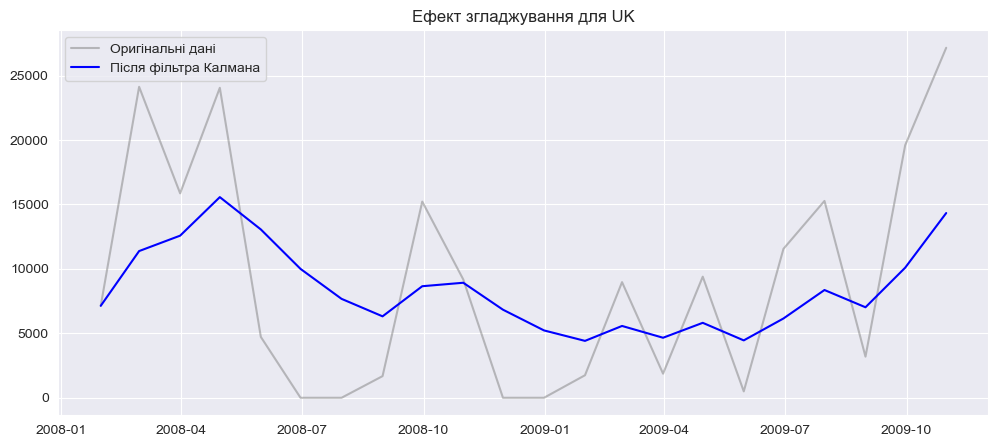

In [137]:
smoothed_sales = monthly_sales.copy()

for country in monthly_sales.columns:
    smoothed_sales[country] = apply_kalman_smoothing(monthly_sales[country])

random_sample = monthly_sales.sum().idxmax()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales[random_sample], label='Оригінальні дані', alpha=0.5, color='gray')
plt.plot(smoothed_sales[random_sample], label='Після фільтра Калмана', color='blue')
plt.title(f'Ефект згладжування для {random_sample}')
plt.legend()
plt.show()

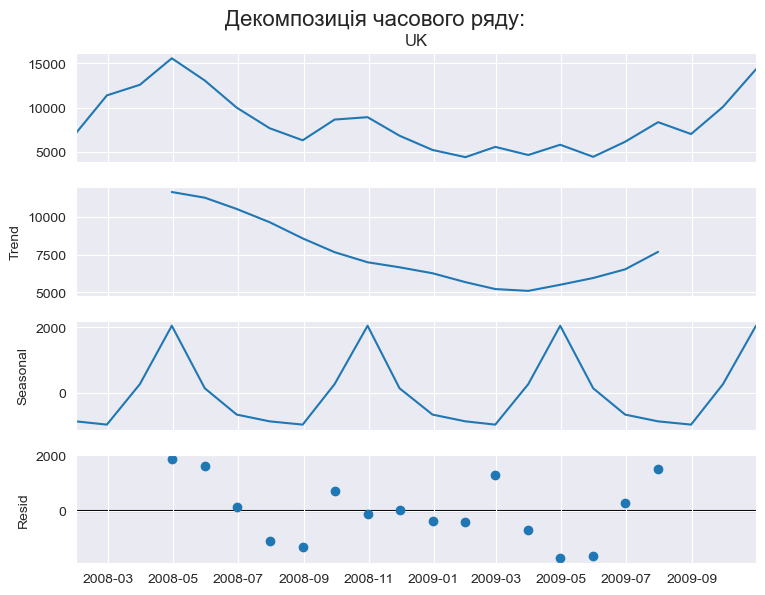

In [138]:
target_series = smoothed_sales[random_sample]

decomposition = seasonal_decompose(target_series, model='additive', period=6)

fig = decomposition.plot()
fig.set_size_inches(8, 6)
plt.suptitle(f"Декомпозиція часового ряду:", fontsize=16, y=1)

plt.show()

In [139]:
smoothed_sales

CustomerCountry,Argentina,Austria,Belgium,Brazil,Canada,Denmark,Finland,France,Germany,Ireland,...,Mexico,Norway,Poland,Portugal,Spain,Sweden,Switzerland,UK,USA,Venezuela
OrderDate,,,,,,,,,,,,,,,,,,,,,
2008-01-31,4536.000000,0.000000,1511.000000,11022.500000,568.950000,237.900000,3523.400000,20232.790000,8456.810000,0.000000,...,660.000000,0.000000,0.000000,735.000000,0.000000,3884.950000,3388.000000,7136.400000,18319.520000,11998.500000
2008-02-29,8157.000000,0.000000,1133.250000,11156.050000,1164.337500,585.925000,3123.612500,17300.220000,7940.520000,0.000000,...,495.000000,0.000000,497.125000,551.250000,17.500000,3461.487500,3062.500000,11385.085000,14977.402500,10412.412500
2008-03-31,8150.753000,693.000000,1167.888000,11020.778900,3798.795100,445.708200,2335.513200,14959.078740,7619.796780,0.000000,...,724.480000,91.472500,381.792000,410.130000,464.790000,3097.118300,2604.916000,12581.402580,14882.818760,12201.134800
2008-04-30,8878.664532,2530.551500,867.636672,13726.084302,3746.843654,339.959501,4344.651921,13140.303703,9343.569144,0.000000,...,543.601920,160.500880,761.884248,1215.414220,1255.056160,2306.299915,3190.729104,15571.318660,13309.932037,10682.812191
2008-05-31,6776.449728,2022.322176,635.238080,11738.424689,2888.468423,259.804953,3496.729798,10008.009625,7634.159169,0.000000,...,405.092388,123.773995,589.882895,917.427140,1113.063663,1694.682316,2383.413725,13063.687412,10323.834861,8171.804047
2008-06-30,5183.982671,1570.899767,453.388158,8832.414005,2245.846197,198.647027,2618.366773,7239.981224,5708.752561,0.000000,...,298.103122,96.436020,461.765180,691.396178,864.367016,1216.522410,1762.617219,10001.365019,7536.252463,6045.828215
2008-07-31,3969.828328,1234.546434,309.270362,8203.137233,1763.117520,151.583905,2112.922288,6967.864032,4516.783499,0.000000,...,705.635804,76.056208,366.149134,518.853637,1301.689309,837.935371,1436.967818,7676.956628,6696.439973,5207.078625
2008-08-31,4870.725481,983.371229,282.209591,7471.081126,1398.713686,114.976971,1551.018642,4788.576987,3430.013907,0.000000,...,525.703746,121.299425,294.559506,386.079875,1018.866139,1059.366458,1253.258608,6319.977457,5459.777484,4071.036358
2008-09-30,3765.391816,795.117578,1166.816613,7822.169981,1602.713671,658.628651,1704.662203,3884.506546,6861.579566,195.000000,...,410.234654,220.462742,355.436932,642.891631,849.190433,1245.018684,1252.451062,8657.139363,5260.354792,3101.584278


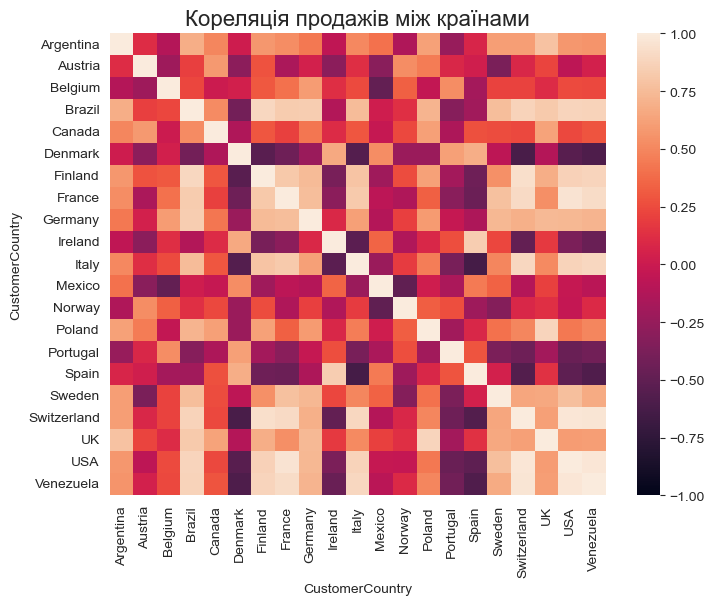

ТОП-5 пар країн з найбільш синхронною динамікою продажів:
CustomerCountry  CustomerCountry
Venezuela        USA                0.976460
Switzerland      USA                0.969750
                 Venezuela          0.965034
France           USA                0.959377
Finland          Switzerland        0.932599
dtype: float64

ТОП-3 пари з оберненою кореляцією:
CustomerCountry  CustomerCountry
Venezuela        Denmark           -0.593396
Switzerland      Denmark           -0.612224
Italy            Spain             -0.640269
dtype: float64


In [140]:
corr_matrix = smoothed_sales.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, vmin=-1, vmax=1)
plt.title("Кореляція продажів між країнами", fontsize=16)
plt.show()

corr_pairs = corr_matrix.unstack(fill_value='hey').sort_values(ascending=False)
corr_pairs = corr_pairs[(corr_pairs < 0.999)]

print("ТОП-5 пар країн з найбільш синхронною динамікою продажів:")
print(corr_pairs.head(10)[::2])

print("\nТОП-3 пари з оберненою кореляцією:")
print(corr_pairs.tail(6)[::2])

Для k=2, Silhouette Score = 0.6271
Для k=3, Silhouette Score = 0.6425
Для k=4, Silhouette Score = 0.4083
Для k=5, Silhouette Score = 0.3855
Для k=6, Silhouette Score = 0.3496
Для k=7, Silhouette Score = 0.3218
Для k=8, Silhouette Score = 0.3117
Для k=9, Silhouette Score = 0.2632


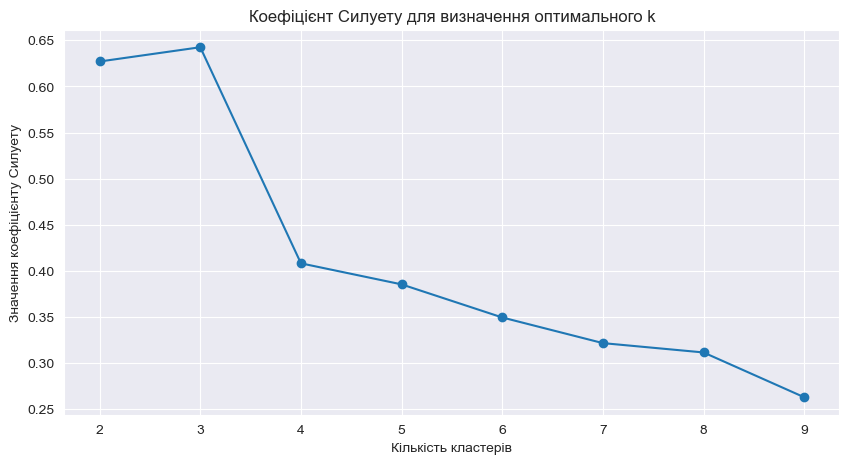

In [141]:
features = pd.DataFrame(index=monthly_sales.columns)
features['Mean_Sales'] = monthly_sales.mean()
features['Trend_Slope'] = smoothed_sales.apply(calculate_ols_slope)
features['Volatility'] = monthly_sales.std()

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features[['Mean_Sales', 'Trend_Slope', 'Volatility']])

k_range = range(2, 10)
best_score = -1
best_k = -1
scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10)
    labels = km.fit_predict(features_scaled)

    score = silhouette_score(features_scaled, labels)
    scores.append(score)

    print(f'Для k={k}, Silhouette Score = {score:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(k_range, scores, marker='o')
plt.title('Коефіцієнт Силуету для визначення оптимального k')
plt.xlabel('Кількість кластерів')
plt.ylabel('Значення коефіцієнту Силуету')
plt.show()

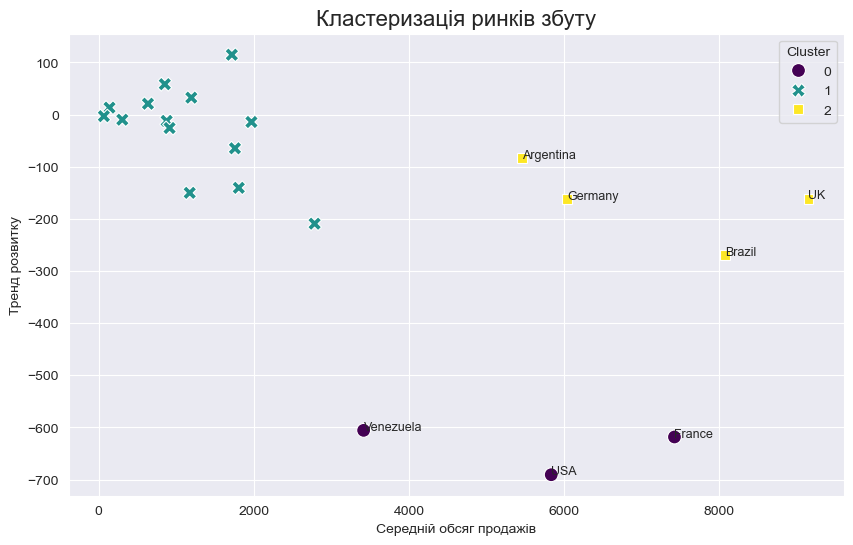

In [24]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, n_init=10)
features['Cluster'] = kmeans.fit_predict(features_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=features, x='Mean_Sales', y='Trend_Slope',
                hue='Cluster', palette='viridis', s=100, style='Cluster')

for i in range(features.shape[0]):
    if features.Mean_Sales.iloc[i] > features.Mean_Sales.mean():
        plt.text(features.Mean_Sales.iloc[i], features.Trend_Slope.iloc[i],
                 features.index[i], fontsize=9)

plt.title("Кластеризація ринків збуту", fontsize=16)
plt.xlabel("Середній обсяг продажів")
plt.ylabel("Тренд розвитку")
plt.show()

Середні показники по кластерах:


,Mean_Sales,Trend_Slope,Volatility
Cluster,,,
0,5556.531364,-638.209040,5363.402045
1,1155.953539,-27.771797,1713.341346
2,7178.338977,-168.959653,6601.396153


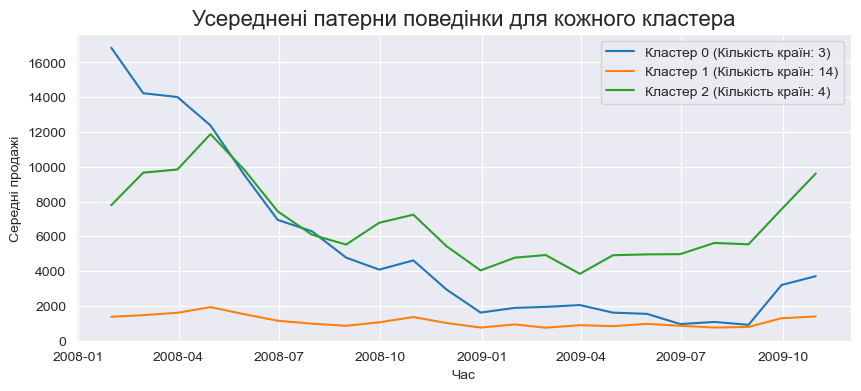

In [25]:
cluster_stats = features.groupby('Cluster')[['Mean_Sales', 'Trend_Slope', 'Volatility']].mean()
print("Середні показники по кластерах:")
display(cluster_stats)

plt.figure(figsize=(10, 4))
for cluster_id in range(n_clusters):
    countries_in_cluster = features[features['Cluster'] == cluster_id].index
    mean_series = smoothed_sales[countries_in_cluster].mean(axis=1)
    plt.plot(mean_series, label=f'Кластер {cluster_id} (Кількість країн: {len(countries_in_cluster)})')

plt.title("Усереднені патерни поведінки для кожного кластера", fontsize=16)
plt.xlabel("Час")
plt.ylabel("Середні продажі")
plt.legend()
plt.show()